
#Flow of This Phase

The flow will be the following:
First, I ranked the regions in Türkiye in terms of average household income in order to determine which region is more affluent and which one has lower subsistence by basics of EDA (Exploratory Data Analysis). Second, by conducting hypothesis testing on a randomized sample from the constructed dataframe, I have determined whether there is a significant relationship between socioeconomic status of the region that people came from and the ranking of the university that people studied at.

#EDA and Visualization Part

Since my aim in this project is to compare economic status in different regions, I examined recent economic status for each region by considering the mean of incomes in past 3 years (2023-2024-2025) I did not go further in time since the economy is unstable, thus it can be misleading. Here is the code to get the average income for each region into another single dataframe and visualization of this constructed dataframe:

<Axes: title={'center': 'Incomes'}, xlabel='REGION'>

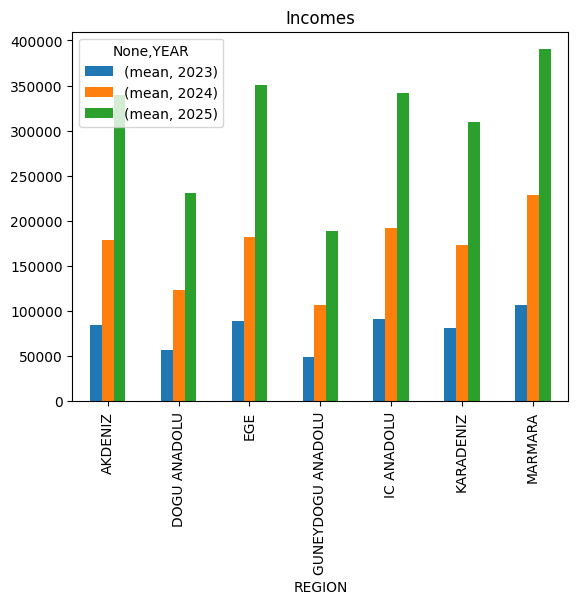

In [ ]:
#Kaan Guler 33887 DSA Project Phase 2 EDA and Visualization Part
import pandas as pd

#data collected from a csv file originally taken from TUIK
df = pd.read_csv("tuik.csv", encoding = "utf-8", encoding_errors = "replace", sep = ",")

regions = { "AKDENIZ", "DOGU ANADOLU", "EGE", "GUNEYDOGU ANADOLU", "IC ANADOLU", "KARADENIZ", "MARMARA" }
years = { "2023", "2024", "2025" }

#creating a temporary table to group regions' incomes and counts to compute average income for each region
table = []

for i in range(len(df)):
  region = df.loc[i, "REGION"]
  for year in years:
    income = df.loc[i, year]
    found = False
    for j in range(len(table)):
      if region == table[j][0]:
        if year == table[j][1]:
          table[j][2] += income
          table[j][3] += 1
          found = True
    if not found:
      table.append([region, year, income, 1])

#computing average income for each region by parsing through temporary table into a new dictionary
dict = { "REGION" : [], "YEAR" : [], "INCOME" : [] }
for i in range(len(table)):
  dict["REGION"].append(table[i][0])
  dict["YEAR"].append(table[i][1])
  dict["INCOME"].append(table[i][2]/table[i][3])

df2 = pd.DataFrame(dict, index = dict['YEAR'])

#converting dataframe into contingency table
ct = pd.crosstab(index = df2['REGION'], columns = df2['YEAR'], values = df2['INCOME'], aggfunc = ["mean"])

#visualizing the income distribution for each region in past 3 years
ct.plot(title="Incomes", kind="bar")



#Inferential Part: Hypothesis Testing

Since the aim is to determine the relationship between two categorical variables (Region-University) best fitting test for this part seems to be chi-square test for independence. Hence, null and alternative hyptheses are the following:


H0 (Null Hypothesis): The resided region (the socioeconomic status) does not determine the accommodation result in terms of the degree of university.


H1 (Alternative Hypothesis): There is a significant impact of the region (socioeconomic status) on the degree of accommodated university.

#Testing Progress

To determine whether to reject the null hypothesis, I selected 10 universities where 5 of them are below 400 in terms of average score while the others are above 400, i.e., 5 of them are high degree, while the others are low degree. By doing this, I could test the impact of socioeconomic status of the region on ranking of the university in average by sample with size 10. Here is the code to merge three distinct accommodation tables (for 2023-2024-2025) into a contingency table to apply chi-square test and extract the p-value.

In [ ]:
#Kaan Guler 33887 DSA Project Phase 2 Testing Part
import numpy as np
import pandas as pd
import scipy.stats as stats

df2023 = pd.read_csv("University_by_ranking_2023.csv", encoding = "utf-8", encoding_errors = "replace", sep = ";")
df2024 = pd.read_csv("University_by_ranking_2024.csv", encoding = "utf-8", encoding_errors = "replace", sep = ";")
df2025 = pd.read_csv("University_by_ranking_2025.csv", encoding = "utf-8", encoding_errors = "replace", sep = ";")

dictGeneral = {}
dictGeneral["Average Score"] = []
dictGeneral["University Name"] = []

#computing the average score for three years in each university into a new dictionary by combining 3 dataframes
for i in range(len(df2023)):
  dictGeneral["University Name"].append(df2023.loc[i, "UNIVERSITY"])
  score2023 = (float(df2023.loc[i, "En Büyük Puan"].replace(",", ".")) + float(df2023.loc[i, "En Küçük Puan"].replace(",", ".")))/2
  score2024 = (float(df2024.loc[i, "En Büyük Puan"].replace(",", ".")) + float(df2024.loc[i, "En Küçük Puan"].replace(",", ".")))/2
  score2025 = (float(df2025.loc[i, "En Büyük Puan"].replace(",", ".")) + float(df2025.loc[i, "En Küçük Puan"].replace(",", ".")))/2
  dictGeneral["Average Score"].append((score2023 + score2024 + score2025)/3)

#constructing a new table combining number of students coming to the university from regions with the score of the university in each line
dfRegion = pd.read_csv("University_by_regions.csv", encoding = "utf-8", encoding_errors = "replace", sep = ",")
dictGeneral["Akdeniz"] = []
dictGeneral["Dogu Anadolu"] = []
dictGeneral["Ege"] = []
dictGeneral["Guneydogu Anadolu"] = []
dictGeneral["Ic Anadolu"] = []
dictGeneral["Karadeniz"] = []
dictGeneral["Marmara"] = []
for i in range(0, len(dfRegion), 3):
  dictGeneral["Akdeniz"].append((int(dfRegion.loc[i, "AKDENIZ"]) + int(dfRegion.loc[i+1, "AKDENIZ"]) + int(dfRegion.loc[i+2, "AKDENIZ"])))
  dictGeneral["Dogu Anadolu"].append((int(dfRegion.loc[i, "DOGU ANADOLU"]) + int(dfRegion.loc[i+1, "DOGU ANADOLU"]) + int(dfRegion.loc[i+2, "DOGU ANADOLU"])))
  dictGeneral["Ege"].append((int(dfRegion.loc[i, "EGE"]) + int(dfRegion.loc[i+1, "EGE"]) + int(dfRegion.loc[i+2, "EGE"])))
  dictGeneral["Guneydogu Anadolu"].append((int(dfRegion.loc[i, "GUNEYDOGU ANADOLU"]) + int(dfRegion.loc[i+1, "GUNEYDOGU ANADOLU"]) + int(dfRegion.loc[i+2, "GUNEYDOGU ANADOLU"])))
  dictGeneral["Ic Anadolu"].append((int(dfRegion.loc[i, "IC ANADOLU"]) + int(dfRegion.loc[i+1, "IC ANADOLU"]) + int(dfRegion.loc[i+2, "IC ANADOLU"])))
  dictGeneral["Karadeniz"].append((int(dfRegion.loc[i, "KARADENIZ"]) + int(dfRegion.loc[i+1, "KARADENIZ"]) + int(dfRegion.loc[i+2, "KARADENIZ"])))
  dictGeneral["Marmara"].append((int(dfRegion.loc[i, "MARMARA"]) + int(dfRegion.loc[i+1, "MARMARA"]) + int(dfRegion.loc[i+2, "MARMARA"])))

dfGeneral = pd.DataFrame(dictGeneral)

#extracting a random sample from the lastly-constructed table
sampleLow = dfGeneral[dfGeneral["Average Score"] < 400].sample(n = 4, random_state = 1)
sampleHigh = dfGeneral[dfGeneral["Average Score"] >= 400].sample(n = 4, random_state = 1)
wholeSample = pd.concat([sampleLow, sampleHigh], ignore_index = True)

wholeSample = wholeSample.drop(columns = "Average Score")
regions = [ "Akdeniz", "Dogu Anadolu", "Ege", "Guneydogu Anadolu", "Ic Anadolu", "Karadeniz", "Marmara"]
dictTabular = { "UNIVERSITY" : [], "REGION" : [], "STUDENT" : [] }
for i in range(len(wholeSample)):
  for r in range(len(regions)):
    dictTabular["UNIVERSITY"].append(wholeSample.loc[i, "University Name"])
    dictTabular["REGION"].append(regions[r])
    dictTabular["STUDENT"].append(wholeSample.loc[i, regions[r]])


tabularSample = pd.DataFrame(dictTabular)

#converting dataframe into contingency table
result = pd.crosstab(index = tabularSample["UNIVERSITY"], columns = tabularSample["REGION"], values = tabularSample["STUDENT"], aggfunc = "max")

#executing chi-square test on the sample
stat, p, dof, expected = stats.chi2_contingency(result)

print()
print("    stat: " + str(stat))
print("       p: " + str(p))
print("     dof: " + str(dof))
print("expected: " + str(expected))
print()


    stat: 1489.6024244030439
       p: 4.0126500164510436e-285
     dof: 42
expected: [[27.2551532  24.03286908 38.13036212 16.37994429 46.18607242 25.5097493
  63.50584958]
 [25.55877437 22.53704735 35.75710306 15.36044568 43.31142061 23.92200557
  59.55320334]
 [12.89247911 11.36824513 18.0367688   7.74818942 21.84735376 12.06685237
  30.04011142]
 [24.31476323 21.44011142 34.01671309 14.61281337 41.20334262 22.75766017
  56.6545961 ]
 [25.55877437 22.53704735 35.75710306 15.36044568 43.31142061 23.92200557
  59.55320334]
 [32.68356546 28.81949861 45.72479109 19.64233983 55.38495822 30.59052925
  76.15431755]
 [29.17771588 25.7281337  40.82005571 17.53537604 49.44401114 27.3091922
  67.98551532]
 [25.55877437 22.53704735 35.75710306 15.36044568 43.31142061 23.92200557
  59.55320334]]



#About P-Value and Test Result

As seen from the output, the p-value is too small, even practically negligable if assumed null hypothesis is true.

###Conclusion:
Being too small of the p-value implies strong rejection of the null hypothesis. Hence, YKS fails to accommodate students in univesities in terms of financial equity.